In [1]:
!pip install -q "ultralytics==8.4.149"

In [2]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
from pathlib import Path
import random
import time

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from zipfile import ZipFile
import torch

from ultralytics import SAM
from ultralytics.models.sam import SAM2Predictor
import ultralytics

In [4]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = 0 if torch.cuda.is_available() else "cpu"

print("Ultralytics:", ultralytics.__version__)
print("PyTorch:", torch.__version__)
print("Device:", DEVICE)

Ultralytics: 8.4.149
PyTorch: 2.11.0+cu128
Device: 0


**Paths**

In [5]:
DATASET_URL = (
    "https://github.com/ultralytics/"
    "assets/releases/download/v0.0.0/"
    "crack-seg.zip"
)

DATASETS_ROOT = Path("/content/datasets")
ARCHIVE_PATH = DATASETS_ROOT / "crack-seg.zip"
DATASET_ROOT = DATASETS_ROOT / "crack-seg"

In [6]:
DATASETS_ROOT.mkdir(parents=True, exist_ok=True)

SPLITS = ("train", "val", "test")
EXPECTED_COUNTS = {
    "train": 3717,
    "val": 200,
    "test": 112,
}

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

print("Dataset root:", DATASET_ROOT)

Dataset root: /content/datasets/crack-seg


In [7]:
dataset_ready = (DATASET_ROOT / "images" / "train").is_dir()

if not dataset_ready:
    if not ARCHIVE_PATH.is_file():
        print("Downloading Crack-Seg...")
        torch.hub.download_url_to_file(
            DATASET_URL, str(ARCHIVE_PATH), progress=True
        )
        
    print("Extracting dataset...")
    with ZipFile(ARCHIVE_PATH, "r") as zip_file:
        zip_file.extractall(DATASETS_ROOT)


if not DATASET_ROOT.is_dir():
    candidates = [
        path for path in DATASETS_ROOT.rglob("*")
        if path.is_dir() and (path / "images").is_dir() and "crack" in path.name.lower()
    ]

    if len(candidates) != 1:
        candidates = [
            path for path in DATASETS_ROOT.rglob("images")
            if path.is_dir()
        ]
        if len(candidates) == 1:
            candidates = [candidates[0].parent]

    if len(candidates) != 1:
        raise FileNotFoundError(
            f"Could not locate Crack-Seg root in {DATASETS_ROOT}. "
            f"Found candidates: {candidates}"
        )

    DATASET_ROOT = candidates[0]

Extracting dataset...


In [8]:
for split in SPLITS:
    required_directories = [
        (DATASET_ROOT / "images" / split),
        (DATASET_ROOT / "labels" / split)
    ]
    
    for directory in (required_directories):
        if not directory.is_dir():
            raise FileExistsError(directory)

print("Dataset extracted:", DATASET_ROOT)

Dataset extracted: /content/datasets


In [9]:
VAL_IMAGES_DIR = DATASET_ROOT/ "images" / "val"
VAL_LABELS_DIR = DATASET_ROOT / "labels" / "val"

OUTPUT_ROOT = Path(
    "/content/drive/MyDrive/"
    "vision_unit_02_outputs/"
    "block_05/"
    "sam2_image"
)

FIGURE_DIR =  OUTPUT_ROOT / "figures"

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


print("Validation images:", VAL_IMAGES_DIR)
print("Validation labels:", VAL_LABELS_DIR)
print("Outputs:", OUTPUT_ROOT)

Validation images: /content/datasets/images/val
Validation labels: /content/datasets/labels/val
Outputs: /content/drive/MyDrive/vision_unit_02_outputs/block_05/sam2_image


**Image index**

In [10]:
validation_image_index = {
    path.stem: path 
    for path in VAL_IMAGES_DIR.iterdir()
    if path.suffix.lower() in IMAGE_EXTENSIONS
}

print("Validation images:", len(validation_image_index))

Validation images: 200


**Polygon → separate instance masks**

In [11]:
def load_instance_masks(image_path, label_path):
    bgr_image = cv2.imread(str(image_path))
    
    if bgr_image is None:
        raise ValueError(f"Cannot read: {image_path}")

    rgb_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)
    height, width = rgb_image.shape[:2]
    
    instance_masks = []
    
    label_text = label_path.read_text(encoding="utf-8").strip()
    if not label_text:
        return rgb_image, instance_masks
    
    for line_number, line in enumerate(label_text.splitlines(), start=1):
        values = line.split()
        
        if (len(values) < 7 or (len(values) - 1) % 2 != 0):
            raise ValueError(
                f"Invalid polygon: "
                f"{label_path.name}, "
                f"line {line_number}"
            )
        
        class_id = int(float(values[0]))
        if class_id != 0:
             raise ValueError(
                f"Unexpected class {class_id}"
            )
        
        normalized_points = np.asarray(values[1:], dtype=np.float32).reshape(-1, 2)
        
        if not np.all((normalized_points >= 0)& (normalized_points <= 1)):
            raise ValueError(
                f"Out-of-bounds polygon: "
                f"{label_path.name}"
            )
        
        pixel_points = np.empty_like(
            normalized_points, dtype=np.int32
        )
        
        pixel_points[:, 0] = np.clip(
            np.rint(normalized_points[:, 0] * width), 0, 
            width - 1
        ).astype(np.int32)
        
        pixel_points[:, 1] = np.clip(
            np.rint(normalized_points[:, 1] * height), 0, 
            height - 1
        ).astype(np.int32)
        
        mask = np.zeros((height, width), dtype=np.uint8)
        
        cv2.fillPoly(mask, [pixel_points], color=1)
        if mask.any():
            instance_masks.append(mask)
    
    return rgb_image, instance_masks

**Prompt and metric utilities**

In [12]:
def binary_iou(prediction, target):
    prediction = prediction > 0
    target = target > 0
    
    intersection = np.logical_and(prediction, target).sum()
    union = np.logical_or(prediction, target).sum()
    
    if union == 0:
        return np.nan
    
    return float(intersection / union)

In [13]:
def binary_dice(prediction, target):
    prediction = prediction > 0
    target = target > 0
    
    intersection = np.logical_and(prediction, target).sum()
    denominator = (prediction.sum() + target.sum())
    
    if denominator == 0:
        return np.nan

    return float(2 * intersection / denominator)

**Positive-point selection**

In [14]:
def find_positive_point(mask):
    distance = cv2.distanceTransform(
        mask.astype(np.uint8), cv2.DIST_L2, 5
    )
    
    y, x = np.unravel_index(
        np.argmax(distance), distance.shape
    )
    
    return int(x), int(y)

In [15]:
def mask_to_box(mask):
    ys, xs = np.where(mask > 0)
    
    if len(xs) == 0:
        raise ValueError("Empty instance mask.")
    
    return [
        int(xs.min()),
        int(ys.min()),
        int(xs.max()),
        int(ys.max()),
    ]

In [16]:
def find_negative_point(mask, padding=15,):
    height, width = mask.shape
    x1, y1, x2, y2 = mask_to_box(mask)

    x1 = max(0, x1 - padding)
    y1 = max(0, y1 - padding)
    x2 = min(width - 1, x2 + padding)
    y2 = min(height - 1, y2 + padding)

    background = (mask == 0).astype(np.uint8)

    distance = cv2.distanceTransform(
        background,cv2.DIST_L2, 5
    )

    valid_region = np.zeros_like(
        mask, dtype=bool
    )

    valid_region[y1:y2 + 1, x1:x2 + 1] = True
    valid_region &= (mask == 0)

    candidate_scores = np.where(
        valid_region,
        distance,
        -1,
    )

    y, x = np.unravel_index(
        np.argmax(candidate_scores),
        candidate_scores.shape,
    )

    return int(x), int(y)

**Build validation instance manifest**

In [17]:
instance_records = []

for label_path in sorted(VAL_LABELS_DIR.glob("*.txt")):
    image_path = validation_image_index.get(label_path.stem)

    if image_path is None:
        continue

    image, masks = load_instance_masks(
        image_path,
        label_path,
    )

    height, width = image.shape[:2]

    for instance_index, mask in enumerate(masks):
        foreground_pixels = int(mask.sum())

        instance_records.append(
            {
                "image_path": str(image_path),
                "label_path": str(label_path),
                "image_name": image_path.name,
                "instance_index": instance_index,
                "foreground_pixels": foreground_pixels,
                "foreground_ratio": foreground_pixels / (height * width),
            }
        )

In [18]:
instance_manifest = pd.DataFrame(instance_records)

print("Validation instances:", len(instance_manifest))
print(
    instance_manifest[
        [
            "foreground_pixels",
            "foreground_ratio",
        ]
    ].describe()
)

Validation instances: 249
       foreground_pixels  foreground_ratio
count         249.000000        249.000000
mean         2822.261044          0.016308
std          2054.272774          0.011871
min            21.000000          0.000121
25%          1310.000000          0.007570
50%          2562.000000          0.014804
75%          3779.000000          0.021837
max         11971.000000          0.069174


**Select nine representative instances**

In [19]:
lower_boundary = (
    instance_manifest["foreground_pixels"].quantile(0.33)
)

upper_boundary = (
    instance_manifest["foreground_pixels"].quantile(0.67)
)

In [20]:
def assign_size_group(pixel_count):
    if pixel_count <= lower_boundary:
        return "small"

    if pixel_count <= upper_boundary:
        return "medium"

    return "large"


instance_manifest["size_group"] = instance_manifest["foreground_pixels"].apply(
    assign_size_group
)

In [21]:
selected_groups = []

for size_group in ["small", "medium","large"]:
    group = (
        instance_manifest[instance_manifest["size_group"] == size_group]
        .sort_values("foreground_pixels")
        .reset_index(drop=True)
    )

    selected_indices = np.linspace(
        0, len(group) - 1,
        3, dtype=int
    )

    selected_groups.append(group.iloc[selected_indices])

In [22]:
selected_instances = pd.concat(selected_groups, ignore_index=True)

selection_path = OUTPUT_ROOT / "sam2_selected_instances.csv"
selected_instances.to_csv(selection_path, index=False)

selected_instances[
    [
        "image_name",
        "instance_index",
        "size_group",
        "foreground_pixels",
        "foreground_ratio",
    ]
]

,image_name,instance_index,size_group,foreground_pixels,foreground_ratio
0,2352.rf.13d894635b7d1c9765f6d1a2404156b7.jpg,1,small,21,0.000121
1,1971.rf.d029ad8edf2ff5e40a416a1399e143ae.jpg,3,small,894,0.005166
2,3228.rf.2bc533ca5e879aecb669ac56ea1c2373.jpg,0,small,1679,0.009702
3,2244.rf.e5270b51e6e7ea41debaf81f16273d7e.jpg,0,medium,1683,0.009725
4,1939.rf.3395d327f8a49d82491b18e04080fee7.jpg,1,medium,2562,0.014804
5,2040.rf.d10ea68f663f198606ec2a816fb7c35b.jpg,0,medium,3300,0.019069
6,3224.rf.ad00820ac18b68d77dc7e662e000df08.jpg,0,large,3308,0.019115
7,3066.rf.3e5fa3c6ece0d8f7337cdf619089fb27.jpg,0,large,4417,0.025524
8,3028.rf.323af1e3d52cd8dfcc7c01e46ce5947c.jpg,0,large,11971,0.069174


**Load SAM2.1 Small**

In [23]:
sam_model = SAM("sam2.1_s.pt")

sam_model.info()

Model summary: 364 layers, 46,060,354 parameters, 46,060,354 gradients


(364, 46060354, 46060354, 0.0)

In [24]:
sam_predictor = SAM2Predictor(
    overrides={
        "model": "sam2.1_s.pt",
        "task": "segment",
        "mode": "predict",
        "device": DEVICE,
        "imgsz": 1024,
        "conf": 0.0,
        "verbose": False,
        "save": False,
    }
)

sam_predictor.setup_model(
    model=sam_model.model,
    verbose=False
)

**SAM result extraction**

In [25]:
def extract_sam_masks(result, target_shape):
    
    if result.masks is None or len(result.masks.data) == 0:
        return (
            np.zeros(
                (0, target_shape[0], target_shape[1]),
                dtype=np.uint8,
            ),
            np.zeros(0, dtype=np.float32),
        )

    masks = result.masks.data.detach().cpu().numpy()
    masks = (masks > 0.5).astype(np.uint8)

    target_height, target_width = target_shape
    resized_masks = []

    for mask in masks:
        if mask.shape != target_shape:
            mask = cv2.resize(
                mask,
                (target_width, target_height),
                interpolation=cv2.INTER_NEAREST,
            )
        resized_masks.append(mask)

    resized_masks = np.stack(resized_masks)

    if result.boxes is not None and result.boxes.conf is not None:
        scores = (
            result.boxes.conf.detach().cpu().numpy().astype(np.float32)
        )
    else:
        scores = np.zeros(
            len(resized_masks),
            dtype=np.float32,
        )

    return resized_masks, scores

**Prompt inference function**

In [26]:
def run_sam_prompt(image_path, image_shape, prompt_type, positive_point=None, negative_point=None, bounding_box=None):
    arguments = {
        "source": str(image_path)
    }
    
    if prompt_type == "point":
        arguments.update({
            "points" : [
                [list(positive_point)]
            ],
            "labels" : [[1]],
            "multimask_output" : True
        })
    elif prompt_type == "positive_negative":
        arguments.update({
            "points" : [
                [list(positive_point), list(negative_point)]
            ],
            "labels" : [[1, 0]],
            "multimask_output" : False
        })
    elif prompt_type == "box":
        arguments.update({
            "bboxes" : list(bounding_box),
            "multimask_output" : False
        })
    else:
        raise ValueError(f"Unknown prompt: {prompt_type}")
    
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    
    start_time = time.perf_counter()
    
    results = sam_predictor(**arguments)
    
    if torch.cuda.is_available():
        torch.cuda.synchronize()
        
    latency_ms = (
        time.perf_counter() - start_time
    ) * 1000
    
    masks, scores = extract_sam_masks(results[0], image_shape)
    
    if len(masks) == 0:
        return {
            "masks": masks,
            "scores": scores,
            "best_index": None,
            "best_mask": np.zeros(
                image_shape,
                dtype=np.uint8,
            ),
            "best_score": np.nan,
            "latency_ms": latency_ms
        }
    
    best_index = int(np.argmax(scores))
    return {
        "masks": masks,
        "scores": scores,
        "best_index": best_index,
        "best_mask": masks[best_index],
        "best_score": float(scores[best_index]),
        "latency_ms": latency_ms
    }

**Warm-up**

In [27]:
warmup_record = selected_instances.iloc[0]

warmup_image, warmup_masks = load_instance_masks(
    Path(warmup_record["image_path"]),
    Path(warmup_record["label_path"]),
)

warmup_mask = warmup_masks[int(warmup_record["instance_index"])]
warmup_point = find_positive_point(warmup_mask)

_ = run_sam_prompt(
    image_path=warmup_record["image_path"],
    image_shape=warmup_mask.shape,
    prompt_type="point",
    positive_point=warmup_point,
)

print("Candidate masks:", len(_["masks"]))
print("Predicted quality scores:", _["scores"])
print("Selected mask index:", _["best_index"])

Candidate masks: 3
Predicted quality scores: [    0.16373     0.51346    0.010725]
Selected mask index: 1


**Evaluate three prompt strategies**

In [28]:
evaluation_rows = []
prediction_cache = {}

for _, record in selected_instances.iterrows():
    image_path = Path(record["image_path"])
    label_path = Path(record["label_path"])

    image, instance_masks = load_instance_masks(image_path, label_path)

    instance_index = int(record["instance_index"])
    ground_truth = instance_masks[instance_index]

    positive_point = find_positive_point(ground_truth)
    negative_point = find_negative_point(ground_truth)
    bounding_box = mask_to_box(ground_truth)

    output_row = {
        "image_name": record["image_name"],
        "instance_index": instance_index,
        "size_group": record["size_group"],
        "foreground_pixels": int(record["foreground_pixels"]),
        "positive_x": positive_point[0],
        "positive_y": positive_point[1],
        "negative_x": negative_point[0],
        "negative_y": negative_point[1],
    }

    prompt_settings = {
        "point": {
            "positive_point": positive_point,
        },
        "positive_negative": {
            "positive_point": positive_point,
            "negative_point": negative_point,
        },
        "box": {
            "bounding_box": bounding_box,
        },
    }
    
    for prompt_name, settings in prompt_settings.items():
        prediction = run_sam_prompt(
            image_path=image_path,
            image_shape=ground_truth.shape,
            prompt_type=prompt_name,
            **settings
        )
        
        output_row[f"{prompt_name}_iou"] = binary_iou(
            prediction["best_mask"],
            ground_truth
        )
        output_row[f"{prompt_name}_dice"] = binary_dice(
            prediction["best_mask"],
            ground_truth
        )
        
        output_row[f"{prompt_name}_score"] = prediction["best_score"]
        
        output_row[f"{prompt_name}_latency_ms"] = prediction["latency_ms"]
        
        output_row[f"{prompt_name}_candidates"] = len(prediction["masks"])
        
        cache_key = (
            record["image_name"],
            instance_index,
            prompt_name,
        )
        
        prediction_cache[cache_key] = prediction

    evaluation_rows.append(output_row)

In [29]:
sam2_metrics = pd.DataFrame(evaluation_rows)

metrics_path = OUTPUT_ROOT / "sam2_prompt_metrics.csv"

sam2_metrics.to_csv(metrics_path, index=False)
sam2_metrics

,image_name,instance_index,size_group,foreground_pixels,positive_x,positive_y,negative_x,negative_y,point_iou,point_dice,...,positive_negative_iou,positive_negative_dice,positive_negative_score,positive_negative_latency_ms,positive_negative_candidates,box_iou,box_dice,box_score,box_latency_ms,box_candidates
0,2352.rf.13d894635b7d1c9765f6d1a2404156b7.jpg,1,small,21,256,200,237,182,0.004941,0.009833,...,0.003715,0.007402,0.577748,188.794393,1,0.341463,0.509091,0.707484,171.676543,1
1,1971.rf.d029ad8edf2ff5e40a416a1399e143ae.jpg,3,small,894,354,122,376,210,0.346457,0.514620,...,0.392727,0.563969,0.567068,174.351903,1,0.534632,0.696756,0.749467,170.076693,1
2,3228.rf.2bc533ca5e879aecb669ac56ea1c2373.jpg,0,small,1679,164,28,107,9,0.696685,0.821231,...,0.689130,0.815959,0.812412,173.639842,1,0.674688,0.805748,0.839299,170.513632,1
3,2244.rf.e5270b51e6e7ea41debaf81f16273d7e.jpg,0,medium,1683,194,53,170,415,0.511650,0.676942,...,0.506032,0.672007,0.761516,175.635968,1,0.474667,0.643762,0.821926,172.775186,1
4,1939.rf.3395d327f8a49d82491b18e04080fee7.jpg,1,medium,2562,319,239,205,214,0.266064,0.420301,...,0.222567,0.364098,0.502436,175.951365,1,0.500364,0.666990,0.539825,173.961343,1
5,2040.rf.d10ea68f663f198606ec2a816fb7c35b.jpg,0,medium,3300,397,202,206,182,0.605107,0.753977,...,0.645815,0.784796,0.757776,170.970864,1,0.584203,0.737535,0.747456,174.184547,1
6,3224.rf.ad00820ac18b68d77dc7e662e000df08.jpg,0,large,3308,101,51,29,415,0.069831,0.130545,...,0.072854,0.135813,0.557534,173.207214,1,0.609591,0.757448,0.690809,175.856464,1
7,3066.rf.3e5fa3c6ece0d8f7337cdf619089fb27.jpg,0,large,4417,196,387,174,16,0.528957,0.691919,...,0.535259,0.697288,0.645087,175.357851,1,0.557099,0.715560,0.781948,171.795907,1
8,3028.rf.323af1e3d52cd8dfcc7c01e46ce5947c.jpg,0,large,11971,124,260,42,171,0.682540,0.811321,...,0.689214,0.816017,0.924400,174.973732,1,0.677856,0.808003,0.953869,174.488983,1


**Prompt comparison summary**

In [30]:
summary_rows = []

for prompt_name in [
    "point",
    "positive_negative",
    "box",
]:
    summary_rows.append(
        {
            "prompt": prompt_name,
            "mean_iou": sam2_metrics[f"{prompt_name}_iou"].mean(),
            "median_iou": sam2_metrics[f"{prompt_name}_iou"].median(),
            "mean_dice": sam2_metrics[f"{prompt_name}_dice"].mean(),
            "mean_predicted_quality": sam2_metrics[
                f"{prompt_name}_score"
            ].mean(),
            "mean_latency_ms": sam2_metrics[
                f"{prompt_name}_latency_ms"
            ].mean(),
        }
    )

prompt_summary = pd.DataFrame(summary_rows).sort_values(
    "mean_iou", ascending=False
)

In [31]:
summary_path = OUTPUT_ROOT / "sam2_prompt_summary.csv"

prompt_summary.to_csv(summary_path, index=False)
prompt_summary

,prompt,mean_iou,median_iou,mean_dice,mean_predicted_quality,mean_latency_ms
2,box,0.550507,0.557099,0.704544,0.759120,172.814366
1,positive_negative,0.417479,0.506032,0.539705,0.678442,175.875904
0,point,0.412470,0.511650,0.536743,0.637230,174.257534


**Performance by mask size**

In [32]:
size_summary_rows = []

for size_group in [
    "small",
    "medium",
    "large",
]:
    subset = sam2_metrics[sam2_metrics["size_group"] == size_group]
    size_summary_rows.append(
        {
            "size_group": size_group,
            "instances": len(subset),
            "point_mean_iou": subset["point_iou"].mean(),
            "positive_negative_mean_iou": subset["positive_negative_iou"].mean(),
            "box_mean_iou": subset["box_iou"].mean(),
        }
    )

size_summary = pd.DataFrame(size_summary_rows)
size_summary

,size_group,instances,point_mean_iou,positive_negative_mean_iou,box_mean_iou
0,small,3,0.349361,0.361858,0.516928
1,medium,3,0.460940,0.458138,0.519745
2,large,3,0.427109,0.432442,0.614849


**Overlay helper**

In [33]:
def create_overlay(image, mask, color=(30, 220, 80), alpha=0.55):
    overlay = image.copy()

    mask_pixels = mask > 0
    color_array = np.asarray(color, dtype=np.float32)

    overlay[
        mask_pixels
    ] = ((1 - alpha)* overlay[mask_pixels] + alpha * color_array
        ).astype(np.uint8)

    return overlay

In [34]:
demo_record = selected_instances.iloc[len(selected_instances) // 2]

demo_image, demo_instances = load_instance_masks(
    Path(demo_record["image_path"]),
    Path(demo_record["label_path"]),
)

demo_index = int(demo_record["instance_index"])
demo_gt = demo_instances[demo_index]

demo_positive = find_positive_point(demo_gt)
demo_negative = find_negative_point(demo_gt)
demo_box = mask_to_box(demo_gt)

In [35]:
point_result = prediction_cache[
    (
        demo_record["image_name"], demo_index, "point"
    )
]

positive_negative_result = prediction_cache[
    (
        demo_record["image_name"], demo_index, "positive_negative"
    )
]

box_result = prediction_cache[
    (
        demo_record["image_name"], demo_index, "box"
    )
]

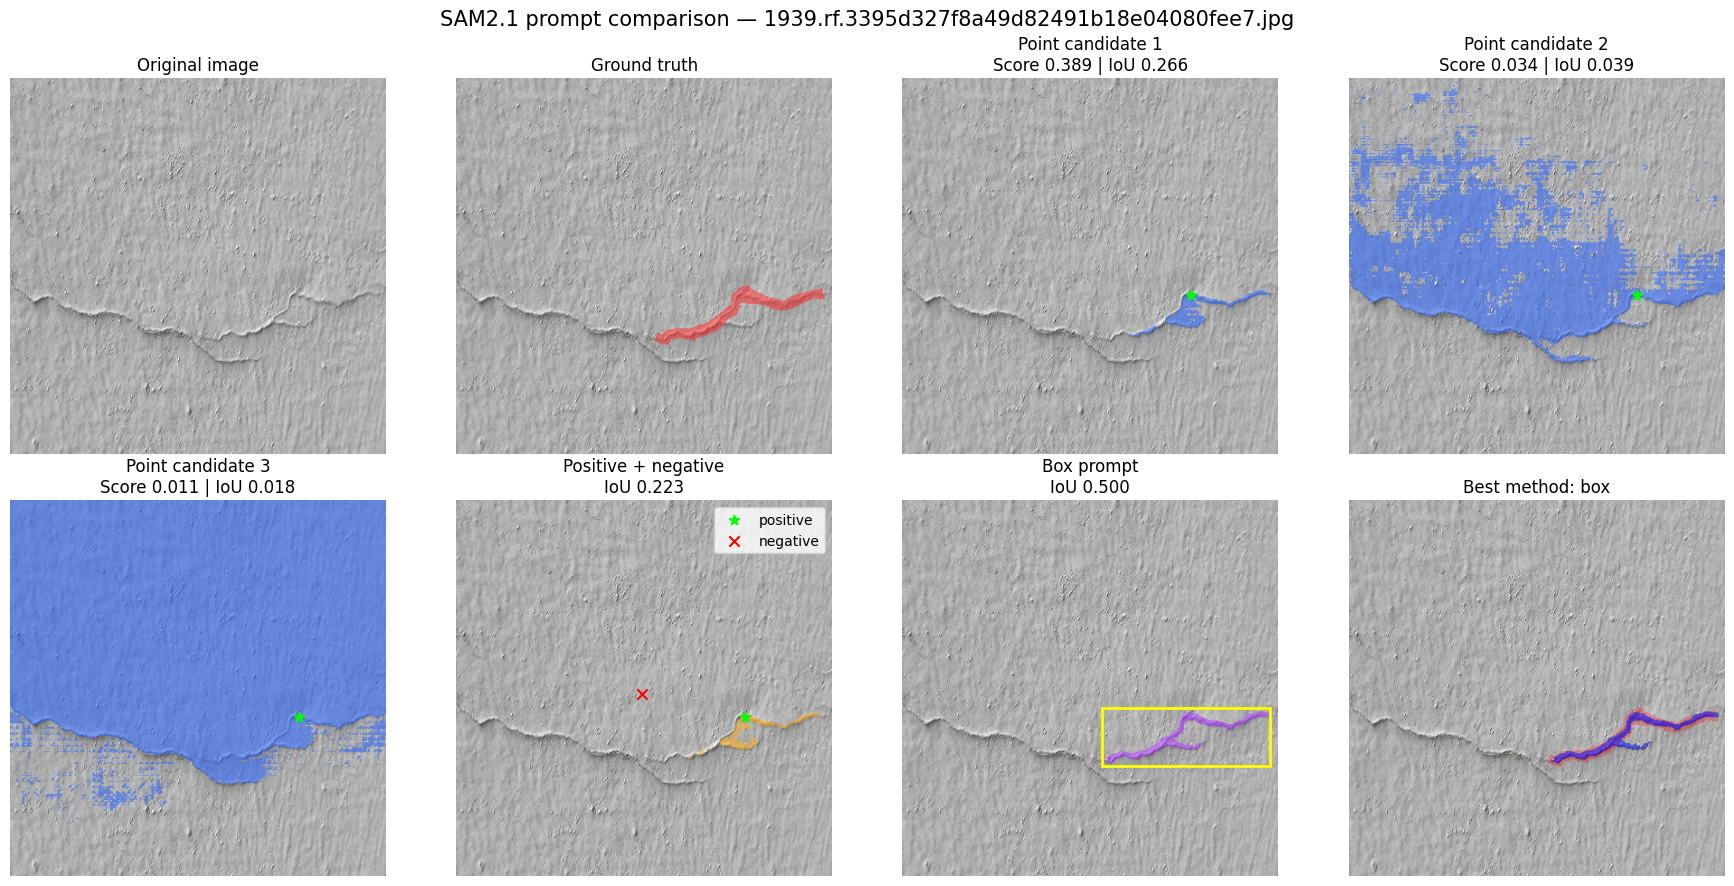

In [36]:
figure, axes = plt.subplots(
    2,
    4,
    figsize=(18, 9),
)

axes = axes.ravel()

axes[0].imshow(demo_image)
axes[0].set_title("Original image")

axes[1].imshow(
    create_overlay(
        demo_image,
        demo_gt,
        color=(255, 50, 50),
    )
)
axes[1].set_title("Ground truth")

candidate_count = min(
    3,
    len(point_result["masks"]),
)

for candidate_index in range(3):
    axis = axes[2 + candidate_index]

    if candidate_index < candidate_count:
        candidate_mask = point_result["masks"][candidate_index]

        candidate_iou = binary_iou(
            candidate_mask,
            demo_gt,
        )

        candidate_score = point_result["scores"][candidate_index]

        axis.imshow(
            create_overlay(
                demo_image,
                candidate_mask,
                color=(40, 100, 255),
            )
        )

        axis.scatter(
            demo_positive[0],
            demo_positive[1],
            c="lime",
            s=60,
            marker="*",
        )

        axis.set_title(
            f"Point candidate {candidate_index + 1}\n"
            f"Score {candidate_score:.3f} | "
            f"IoU {candidate_iou:.3f}"
        )

    else:
        axis.axis("off")

axes[5].imshow(
    create_overlay(
        demo_image,
        positive_negative_result["best_mask"],
        color=(255, 170, 20),
    )
)

axes[5].scatter(
    demo_positive[0],
    demo_positive[1],
    c="lime",
    s=60,
    marker="*",
    label="positive",
)

axes[5].scatter(
    demo_negative[0],
    demo_negative[1],
    c="red",
    s=55,
    marker="x",
    label="negative",
)

axes[5].legend()

axes[5].set_title(
    "Positive + negative\n"
    f"IoU {binary_iou(positive_negative_result['best_mask'], demo_gt):.3f}"
)

axes[6].imshow(
    create_overlay(
        demo_image,
        box_result["best_mask"],
        color=(170, 50, 255),
    )
)

x1, y1, x2, y2 = demo_box

axes[6].add_patch(
    plt.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        fill=False,
        color="yellow",
        linewidth=2,
    )
)

axes[6].set_title(
    "Box prompt\n" f"IoU {binary_iou(box_result['best_mask'], demo_gt):.3f}"
)

best_method = prompt_summary.iloc[0]["prompt"]

best_result = prediction_cache[
    (
        demo_record["image_name"],
        demo_index,
        best_method,
    )
]

axes[7].imshow(
    create_overlay(
        demo_image,
        demo_gt,
        color=(255, 40, 40),
        alpha=0.35,
    )
)

axes[7].imshow(
    np.ma.masked_where(
        best_result["best_mask"] == 0,
        best_result["best_mask"],
    ),
    cmap="winter",
    alpha=0.55,
)

axes[7].set_title(f"Best method: {best_method}")

for axis in axes:
    axis.axis("off")

figure.suptitle(
    f"SAM2.1 prompt comparison — {demo_record['image_name']}",
    fontsize=15,
)

figure.tight_layout()
comparison_figure_path = FIGURE_DIR / "sam2_prompt_comparison.png"

figure.savefig(
    comparison_figure_path, dpi=180, bbox_inches="tight" 
)

plt.show()

**Point sensitivity experiment**

In [37]:
POINT_OFFSETS = [
    (0, 0),
    (-5, 0),
    (5, 0),
    (0, -5),
    (0, 5),
]


sensitivity_rows = []
height, width = demo_gt.shape

for dx, dy in POINT_OFFSETS:
    shifted_point = (
        int(
            np.clip(demo_positive[0] + dx, 0, width - 1)
        ),
        int(
            np.clip(demo_positive[1] + dy, 0, height - 1)
        ),
    )
    
    prediction = run_sam_prompt(
        image_path=demo_record["image_path"],
        image_shape=demo_gt.shape,
        prompt_type="point",
        positive_point=shifted_point,
    )
    
    sensitivity_rows.append(
        {
            "dx": dx,
            "dy": dy,
            "point_x": shifted_point[0],
            "point_y": shifted_point[1],
            "point_inside_gt": bool(
                demo_gt[
                    shifted_point[1], shifted_point[0]
                ]
            ),
            "predicted_quality": (
                prediction["best_score"]
            ),
            "iou": binary_iou(
                prediction["best_mask"],
                demo_gt,
            ),
            "dice": binary_dice(
                prediction["best_mask"],
                demo_gt,
            ),
        }
    )

In [38]:
sensitivity_table = pd.DataFrame(sensitivity_rows)

sensitivity_path = OUTPUT_ROOT / "sam2_prompt_sensitivity.csv"
sensitivity_table.to_csv(sensitivity_path, index=False)

sensitivity_table

,dx,dy,point_x,point_y,point_inside_gt,predicted_quality,iou,dice
0,0,0,319,239,True,0.389137,0.266064,0.420301
1,-5,0,314,239,True,0.435906,0.235721,0.381512
2,5,0,324,239,True,0.307221,0.014409,0.028409
3,0,-5,319,234,True,0.905335,0.014693,0.028960
4,0,5,319,244,True,0.727627,0.098014,0.178530


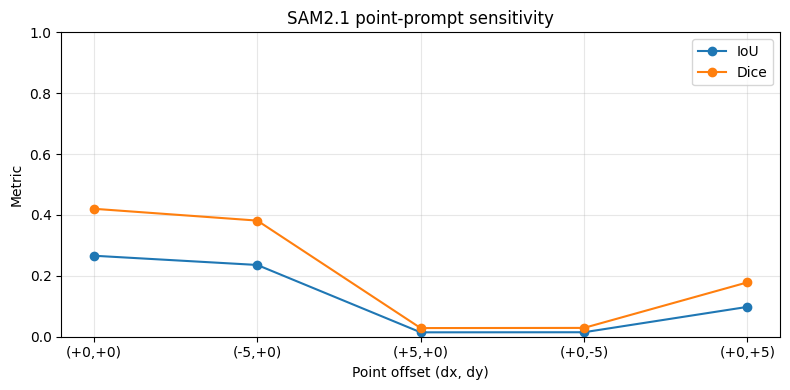

In [39]:
labels = [
    f"({row.dx:+d},{row.dy:+d})"
    for row in sensitivity_table.itertuples()
]

figure, axis = plt.subplots(figsize=(8, 4))

axis.plot(
    labels,
    sensitivity_table["iou"],
    marker="o",
    label="IoU",
)

axis.plot(
    labels,
    sensitivity_table["dice"],
    marker="o",
    label="Dice",
)

axis.set_xlabel("Point offset (dx, dy)")
axis.set_ylabel("Metric")
axis.set_ylim(0, 1)

axis.set_title("SAM2.1 point-prompt sensitivity")
axis.grid(alpha=0.3)
axis.legend()

figure.tight_layout()

sensitivity_figure_path = FIGURE_DIR / "sam2_prompt_sensitivity.png"


figure.savefig(
    sensitivity_figure_path,
    dpi=180,
    bbox_inches="tight",
)

plt.show()

In [40]:
required_outputs = [
    selection_path, metrics_path,
    summary_path, comparison_figure_path,
    sensitivity_path, sensitivity_figure_path,
]

missing_outputs = [
    path for path in required_outputs if not path.is_file()
]

if missing_outputs:
    print("Missing outputs:")

    for path in missing_outputs:
        print("-", path)

    raise RuntimeError("SAM2.1 image stage incomplete.")

if len(selected_instances) != 9:
    raise RuntimeError("Expected 9 evaluation instances.")

if len(sam2_metrics) != 9:
    raise RuntimeError("Metrics table is incomplete.")

print("=" * 60)
print("BLOCK 5A-I COMPLETE")
print("=" * 60)

print(prompt_summary)
print(size_summary)

BLOCK 5A-I COMPLETE
              prompt  mean_iou  median_iou  mean_dice  mean_predicted_quality  \
2                box  0.550507    0.557099   0.704544                0.759120   
1  positive_negative  0.417479    0.506032   0.539705                0.678442   
0              point  0.412470    0.511650   0.536743                0.637230   

   mean_latency_ms  
2       172.814366  
1       175.875904  
0       174.257534  
  size_group  instances  point_mean_iou  positive_negative_mean_iou  \
0      small          3        0.349361                    0.361858   
1     medium          3        0.460940                    0.458138   
2      large          3        0.427109                    0.432442   

   box_mean_iou  
0      0.516928  
1      0.519745  
2      0.614849  


### Video Propagation and Assisted Annotation

**Stage directories**

In [41]:
import gc
import json
import subprocess

from ultralytics.models.sam import SAM2VideoPredictor

In [42]:
VIDEO_DIR = OUTPUT_ROOT/ "video"
ANNOTATION_DIR = OUTPUT_ROOT / "assisted_annotation"


VIDEO_DIR.mkdir(parents=True, exist_ok=True)
ANNOTATION_DIR.mkdir(parents=True,exist_ok=True)

**SAM mask → draft YOLO polygons**

In [43]:
def mask_to_yolo_polygons(
    mask,
    class_id=0,
    minimum_contour_area=5,
):
    height, width = mask.shape

    contours, _ = cv2.findContours(
        mask.astype(np.uint8),
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE,
    )

    label_lines = []

    for contour in sorted(
        contours,
        key=cv2.contourArea,
        reverse=True,
    ):
        if cv2.contourArea(contour) < minimum_contour_area:
            continue

        perimeter = cv2.arcLength(contour,closed=True)

        simplified = cv2.approxPolyDP(
            contour,
            epsilon=0.002 * perimeter,
            closed=True,
        )

        points = simplified.reshape(-1, 2)

        if len(points) < 3:
            continue

        normalized_values = []

        for x, y in points:
            normalized_values.extend(
                [
                    float(x) / width,
                    float(y) / height,
                ]
            )

        coordinate_text = " ".join(
            f"{value:.6f}" for value in normalized_values
        )

        label_lines.append(f"{class_id} {coordinate_text}")

    return label_lines

In [44]:
assisted_mask = box_result["best_mask"]

draft_label_lines = mask_to_yolo_polygons(assisted_mask)

if not draft_label_lines:
    raise RuntimeError("No valid draft polygon created.")

draft_label_path = (
    ANNOTATION_DIR / f"{demo_record['image_name']}.txt"
)

draft_label_path.write_text(
    "\n".join(draft_label_lines),
    encoding="utf-8",
)

print("Draft polygons:", len(draft_label_lines))
print("Draft label:", draft_label_path)

Draft polygons: 1
Draft label: /content/drive/MyDrive/vision_unit_02_outputs/block_05/sam2_image/assisted_annotation/1939.rf.3395d327f8a49d82491b18e04080fee7.jpg.txt


**Annotation preview**

In [45]:
annotation_preview = demo_image.copy()


predicted_contours, _ = (
    cv2.findContours(
        assisted_mask.astype(np.uint8),
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE,
    )
)

cv2.drawContours(
    annotation_preview,
    predicted_contours,
    -1,
    color=(170, 40, 255),
    thickness=2,
)

x1, y1, x2, y2 = demo_box

cv2.rectangle(
    annotation_preview,
    (x1, y1),
    (x2, y2),
    color=(255, 220, 20),
    thickness=2,
)

array([[[163, 163, 163],
        [156, 156, 156],
        [156, 156, 156],
        ...,
        [171, 171, 171],
        [169, 169, 169],
        [170, 170, 170]],

       [[157, 157, 157],
        [155, 155, 155],
        [159, 159, 159],
        ...,
        [169, 169, 169],
        [169, 169, 169],
        [170, 170, 170]],

       [[153, 153, 153],
        [155, 155, 155],
        [165, 165, 165],
        ...,
        [167, 167, 167],
        [168, 168, 168],
        [170, 170, 170]],

       ...,

       [[152, 152, 152],
        [158, 158, 158],
        [168, 168, 168],
        ...,
        [171, 171, 171],
        [166, 166, 166],
        [163, 163, 163]],

       [[157, 157, 157],
        [164, 164, 164],
        [175, 175, 175],
        ...,
        [168, 168, 168],
        [163, 163, 163],
        [160, 160, 160]],

       [[162, 162, 162],
        [170, 170, 170],
        [181, 181, 181],
        ...,
        [167, 167, 167],
        [161, 161, 161],
        [157, 157, 157]]

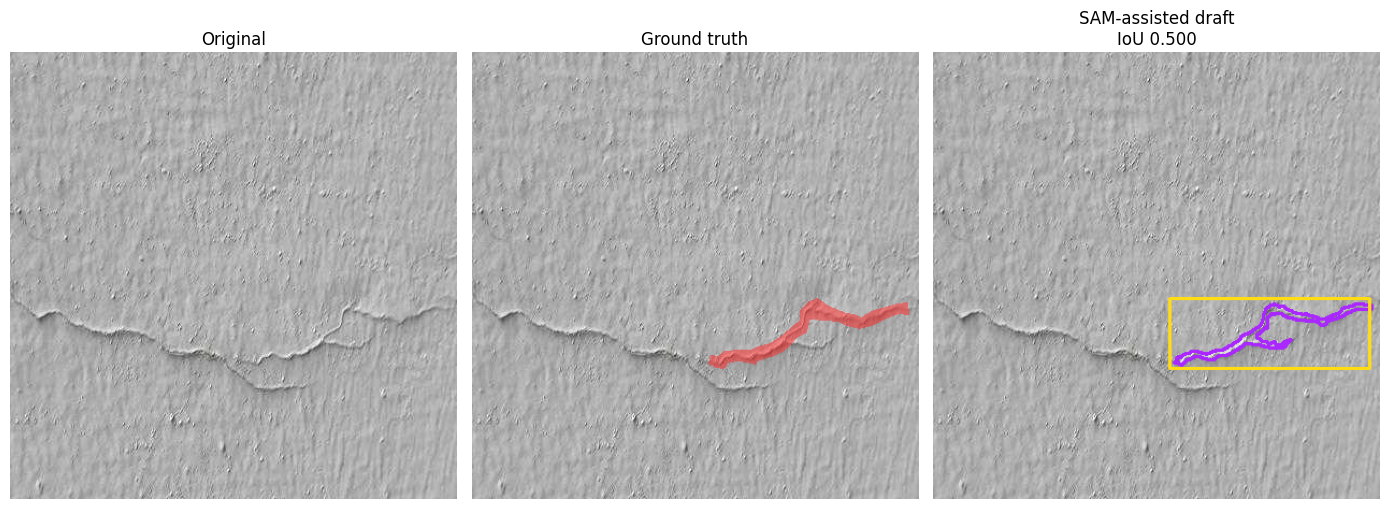

In [46]:
figure, axes = plt.subplots(1, 3, figsize=(14, 5))

axes[0].imshow(demo_image)
axes[0].set_title("Original")

axes[1].imshow(
    create_overlay(
        demo_image,
        demo_gt,
        color=(255, 50, 50),
    )
)
axes[1].set_title("Ground truth")

axes[2].imshow(
    annotation_preview
)
axes[2].set_title(
    "SAM-assisted draft\n"
    f"IoU "
    f"{binary_iou(assisted_mask, demo_gt):.3f}"
)

for axis in axes:
    axis.axis("off")

figure.tight_layout()

annotation_preview_path = (
    ANNOTATION_DIR
    / "sam_assisted_annotation_preview.png"
)

figure.savefig(
    annotation_preview_path,
    dpi=180,
    bbox_inches="tight",
)

plt.show()

**Create controlled short video**

In [47]:
FRAME_COUNT = 30
VIDEO_FPS = 5

height, width = demo_image.shape[:2]

raw_input_video_path = VIDEO_DIR / "sam2_controlled_input.avi"
input_video_path = VIDEO_DIR / "sam2_controlled_input.mp4"
ground_truth_path = VIDEO_DIR / "sam2_controlled_gt_masks.npz"

In [48]:
video_writer = cv2.VideoWriter(
    str(raw_input_video_path),
    cv2.VideoWriter_fourcc(*"MJPG"),
    VIDEO_FPS,
    (width, height)
)

if not video_writer.isOpened():
    raise RuntimeError("Input video writer failed.")

source_bgr = cv2.cvtColor(demo_image, cv2.COLOR_RGB2BGR)

video_ground_truths = []

for frame_index in range(FRAME_COUNT):
    phase = (
        2
        * np.pi
        * frame_index
        / (FRAME_COUNT - 1)
    )

    dx = 8 * np.sin(phase)
    dy = 5 * np.sin(2 * phase)
    angle = 2 * np.sin(phase)
    scale = 1 + 0.015 * np.sin(phase)

    transformation = cv2.getRotationMatrix2D(
        center=(
            width / 2,
            height / 2,
        ),
        angle=angle,
        scale=scale
    )

    transformation[0, 2] += dx
    transformation[1, 2] += dy

    transformed_frame = cv2.warpAffine(
        source_bgr,
        transformation,
        (width, height),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_REFLECT_101
    )

    transformed_mask = cv2.warpAffine(
        demo_gt,
        transformation,
        (width, height),
        flags=cv2.INTER_NEAREST,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=0
    )

    video_writer.write(transformed_frame)

    video_ground_truths.append(
        transformed_mask.astype(np.uint8)
    )

video_writer.release()
video_ground_truths = np.stack(video_ground_truths)

np.savez_compressed(
    ground_truth_path,
    masks=video_ground_truths
)

In [49]:
subprocess.run(
    [
        "ffmpeg",
        "-y",
        "-loglevel",
        "error",
        "-i",
        str(raw_input_video_path),
        "-c:v",
        "libx264",
        "-pix_fmt",
        "yuv420p",
        "-movflags",
        "+faststart",
        str(input_video_path),
    ],
    check=True,
)

print("Frames:", FRAME_COUNT)
print("Input video:", input_video_path)

Frames: 30
Input video: /content/drive/MyDrive/vision_unit_02_outputs/block_05/sam2_image/video/sam2_controlled_input.mp4


In [50]:
del sam_model
del prediction_cache

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

**Create notebook-safe video predictor**

In [51]:
video_overrides = {
    "model" : "sam2.1_s.pt",
    "task" : "segment",
    "mode" : "predict",
    "imgsz" : 1024,
    "conf" : 0.25,
    "device" : DEVICE,
    "save" : False,
    "verbose" : False
}

video_predictor = (
    SAM2VideoPredictor(
        overrides=video_overrides
    )
)

**Propagate initial box prompt**

In [52]:
raw_output_video_path = (
    VIDEO_DIR
    / "sam2_propagation_output.avi"
)

output_video_path = (
    VIDEO_DIR
    / "sam2_propagation_output.mp4"
)

In [53]:
def overlay_mask_bgr(frame, mask, color=(40, 220, 40), alpha=0.45):
    output = frame.copy()
    selected = mask > 0

    color_array = np.asarray(
        color,
        dtype=np.float32,
    )

    output[selected] = (
        (1 - alpha) * output[selected]
        + alpha * color_array
    ).astype(np.uint8)

    return output

In [54]:
prediction_stream = video_predictor(
    source=str(input_video_path),
    bboxes=demo_box,
    stream=True
)

In [55]:
output_writer = cv2.VideoWriter(
    str(raw_output_video_path),
    cv2.VideoWriter_fourcc(*"MJPG"),
    VIDEO_FPS, (width, height)
)

if not output_writer.isOpened():
    raise RuntimeError("Output video writer failed")

In [56]:
frame_metric_rows = []

for frame_index, result in enumerate(prediction_stream):
    frame = result.orig_img.copy()

    if result.masks is not None and len(result.masks.data) > 0:
        predicted_mask = result.masks.data[0].detach().cpu().numpy()
        predicted_mask = (predicted_mask > 0.5).astype(np.uint8)

        if predicted_mask.shape != (height, width):
            predicted_mask = cv2.resize(
                predicted_mask,
                (width, height),
                interpolation=cv2.INTER_NEAREST,
            )
    else:
        predicted_mask = np.zeros((height, width), dtype=np.uint8)

    ground_truth = video_ground_truths[frame_index]

    frame_iou = binary_iou(predicted_mask, ground_truth)
    frame_dice = binary_dice(predicted_mask, ground_truth)

    visualization = overlay_mask_bgr(frame, predicted_mask)

    gt_contours, _ = cv2.findContours(
        ground_truth.astype(np.uint8),
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE,
    )

    cv2.drawContours(
        visualization,
        gt_contours,
        -1,
        color=(0, 255, 255),
        thickness=1,
    )

    cv2.putText(
        visualization,
        f"Frame {frame_index:02d} IoU {frame_iou:.3f}",
        (12, 28),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.65,
        (255, 255, 255),
        2,
        cv2.LINE_AA,
    )

    output_writer.write(visualization)
    speed = result.speed or {}

    frame_metric_rows.append(
        {
            "frame_index": frame_index,
            "mask_found": bool(predicted_mask.any()),
            "predicted_pixels": int(predicted_mask.sum()),
            "gt_pixels": int(ground_truth.sum()),
            "iou": frame_iou,
            "dice": frame_dice,
            "preprocess_ms": float(speed.get("preprocess", np.nan)),
            "inference_ms": float(speed.get("inference", np.nan)),
            "postprocess_ms": float(speed.get("postprocess", np.nan)),
        }
    )

output_writer.release()

Ultralytics 8.4.149 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)


In [57]:
subprocess.run(
    [
        "ffmpeg",
        "-y",
        "-loglevel",
        "error",
        "-i",
        str(raw_output_video_path),
        "-c:v",
        "libx264",
        "-pix_fmt",
        "yuv420p",
        "-movflags",
        "+faststart",
        str(output_video_path),
    ],
    check=True,
)

print("Propagation video:",output_video_path)

Propagation video: /content/drive/MyDrive/vision_unit_02_outputs/block_05/sam2_image/video/sam2_propagation_output.mp4


**Video metrics**

In [58]:
video_metrics = pd.DataFrame(
    frame_metric_rows
)

video_metrics_path = (
    VIDEO_DIR
    / "sam2_video_frame_metrics.csv"
)

video_metrics.to_csv(
    video_metrics_path,
    index=False,
)

In [59]:
mean_pipeline_ms = (
    video_metrics[
        [
            "preprocess_ms",
            "inference_ms",
            "postprocess_ms",
        ]
    ]
    .sum(axis=1)
    .mean()
)

video_summary = {
    "video_type": (
        "controlled_synthetic_camera_motion"
    ),
    "initial_prompt": "box",
    "frames": len(video_metrics),
    "fps": VIDEO_FPS,
    "mean_iou": float(
        video_metrics["iou"].mean()
    ),
    "minimum_iou": float(
        video_metrics["iou"].min()
    ),
    "first_frame_iou": float(
        video_metrics.iloc[0]["iou"]
    ),
    "last_frame_iou": float(
        video_metrics.iloc[-1]["iou"]
    ),
    "mean_dice": float(
        video_metrics["dice"].mean()
    ),
    "mask_retention_rate": float(
        video_metrics[
            "mask_found"
        ].mean()
    ),
    "mean_pipeline_ms": float(
        mean_pipeline_ms
    ),
    "theoretical_fps": float(
        1000 / mean_pipeline_ms
    )
    if mean_pipeline_ms > 0
    else None,
    "test_split_used": False,
}

In [60]:
video_summary_path = (
    VIDEO_DIR
    / "sam2_video_summary.json"
)

video_summary_path.write_text(
    json.dumps(
        video_summary, indent=2
    ),encoding="utf-8"
)

print(
    json.dumps(video_summary, indent=2)
)

{
  "video_type": "controlled_synthetic_camera_motion",
  "initial_prompt": "box",
  "frames": 30,
  "fps": 5,
  "mean_iou": 0.4991868609652835,
  "minimum_iou": 0.48142907675981605,
  "first_frame_iou": 0.5068890500362582,
  "last_frame_iou": 0.507505360972123,
  "mean_dice": 0.6659095714665882,
  "mask_retention_rate": 1.0,
  "mean_pipeline_ms": 460.2249529333373,
  "theoretical_fps": 2.172850458512292,
  "test_split_used": false
}


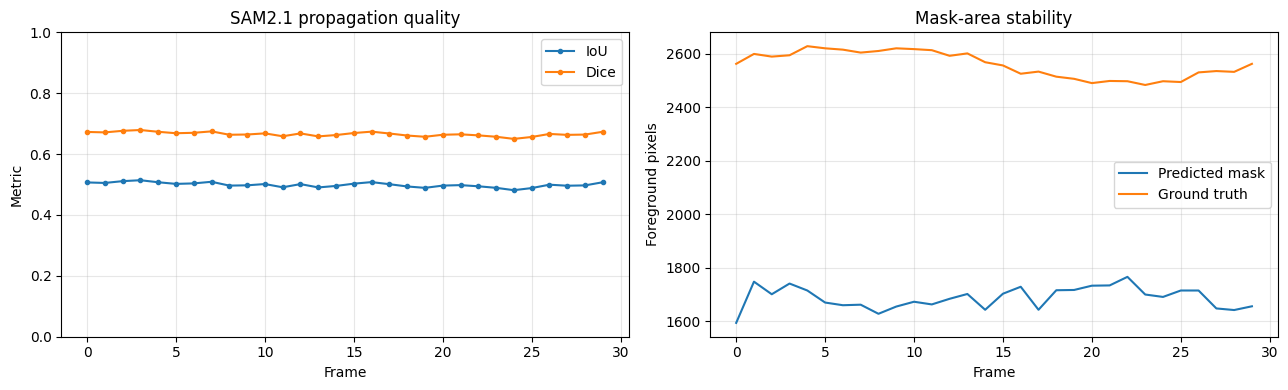

In [61]:
figure, axes = plt.subplots(
    1,
    2,
    figsize=(13, 4),
)

axes[0].plot(
    video_metrics[
        "frame_index"
    ],
    video_metrics["iou"],
    marker="o",
    markersize=3,
    label="IoU",
)

axes[0].plot(
    video_metrics[
        "frame_index"
    ],
    video_metrics["dice"],
    marker="o",
    markersize=3,
    label="Dice",
)

axes[0].set_ylim(0, 1)
axes[0].set_xlabel("Frame")
axes[0].set_ylabel("Metric")
axes[0].set_title(
    "SAM2.1 propagation quality"
)
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(
    video_metrics[
        "frame_index"
    ],
    video_metrics[
        "predicted_pixels"
    ],
    label="Predicted mask",
)

axes[1].plot(
    video_metrics[
        "frame_index"
    ],
    video_metrics[
        "gt_pixels"
    ],
    label="Ground truth",
)

axes[1].set_xlabel("Frame")
axes[1].set_ylabel("Foreground pixels")
axes[1].set_title(
    "Mask-area stability"
)
axes[1].grid(alpha=0.3)
axes[1].legend()

figure.tight_layout()

temporal_figure_path = (
    VIDEO_DIR
    / "sam2_temporal_metrics.png"
)

figure.savefig(
    temporal_figure_path,
    dpi=180,
    bbox_inches="tight",
)

plt.show()

In [62]:
len(video_metrics)

30

In [63]:
required_outputs = [
    draft_label_path,
    annotation_preview_path,
    input_video_path,
    ground_truth_path,
    output_video_path,
    video_metrics_path,
    video_summary_path,
    temporal_figure_path,
]

missing_outputs = [
    path
    for path in required_outputs
    if not path.is_file()
]

if missing_outputs:
    for path in missing_outputs:
        print("Missing:", path)

    raise RuntimeError(
        "Block 5A-II incomplete."
    )

if len(video_metrics) != FRAME_COUNT:
    raise RuntimeError(
        "Not all video frames processed."
    )

print("=" * 60)
print("BLOCK 5A-II COMPLETE")
print("=" * 60)

print("Draft polygons:",len(draft_label_lines))

print(
    "Mean video IoU:",
    round(
        video_summary["mean_iou"],
        4,
    ),
)

print(
    "Mask retention:",
    round(
        video_summary[
            "mask_retention_rate"
        ],
        4,
    ),
)

print(
    "Output video:",
    output_video_path,
)

BLOCK 5A-II COMPLETE
Draft polygons: 1
Mean video IoU: 0.4992
Mask retention: 1.0
Output video: /content/drive/MyDrive/vision_unit_02_outputs/block_05/sam2_image/video/sam2_propagation_output.mp4
